In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

base_path = '/content/drive/MyDrive/Aerial Object Classification & Detection'

for item in os.listdir(base_path):
    print(item)

test-20260409T091319Z-3-001
valid-20260409T091319Z-3-001
train-20260409T091319Z-3-001


In [5]:
folders = [
    'train-20260409T091319Z-3-001',
    'valid-20260409T091319Z-3-001',
    'test-20260409T091319Z-3-001'
]

for folder in folders:
    path = os.path.join(base_path, folder)
    print(f"\n📁 {folder}:")
    if os.path.isdir(path):
        for item in os.listdir(path):
            print(f"   └── {item}")
    else:
        print(f"   (Not a directory or does not exist: {path})")


📁 train-20260409T091319Z-3-001:
   └── train

📁 valid-20260409T091319Z-3-001:
   └── valid

📁 test-20260409T091319Z-3-001:
   └── test


In [6]:
for folder in folders:
    path = os.path.join(base_path, folder)
    for subfolder in os.listdir(path):
        sub_path = os.path.join(path, subfolder)
        if os.path.isdir(sub_path):
            print(f"\n📁 {folder} → {subfolder}:")
            for item in os.listdir(sub_path):
                print(f"   └── {item}")


📁 train-20260409T091319Z-3-001 → train:
   └── drone
   └── bird

📁 valid-20260409T091319Z-3-001 → valid:
   └── drone
   └── bird

📁 test-20260409T091319Z-3-001 → test:
   └── drone
   └── bird


EDA

In [7]:
from google.colab import drive
drive.mount('/content/drive')

import os

base = '/content/drive/MyDrive/Aerial Object Classification & Detection'

TRAIN_DIR = os.path.join(base, 'train-20260409T091319Z-3-001/train/')
VALID_DIR = os.path.join(base, 'valid-20260409T091319Z-3-001/valid/')
TEST_DIR  = os.path.join(base, 'test-20260409T091319Z-3-001/test/')

print("✅ Paths Set Successfully!")
print("TRAIN:", TRAIN_DIR)
print("VALID:", VALID_DIR)
print("TEST :", TEST_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Paths Set Successfully!
TRAIN: /content/drive/MyDrive/Aerial Object Classification & Detection/train-20260409T091319Z-3-001/train/
VALID: /content/drive/MyDrive/Aerial Object Classification & Detection/valid-20260409T091319Z-3-001/valid/
TEST : /content/drive/MyDrive/Aerial Object Classification & Detection/test-20260409T091319Z-3-001/test/


In [8]:
#Checking the count of images
for split_name, split_path in [('TRAIN', TRAIN_DIR), ('VALID', VALID_DIR), ('TEST', TEST_DIR)]:
    print(f"\n📁 {split_name}:")
    for cls in ['bird', 'drone']:
        cls_path = os.path.join(split_path, cls)
        count = len(os.listdir(cls_path))
        print(f"   {cls}: {count} images")


📁 TRAIN:
   bird: 1414 images
   drone: 1248 images

📁 VALID:
   bird: 217 images
   drone: 225 images

📁 TEST:
   bird: 126 images
   drone: 94 images


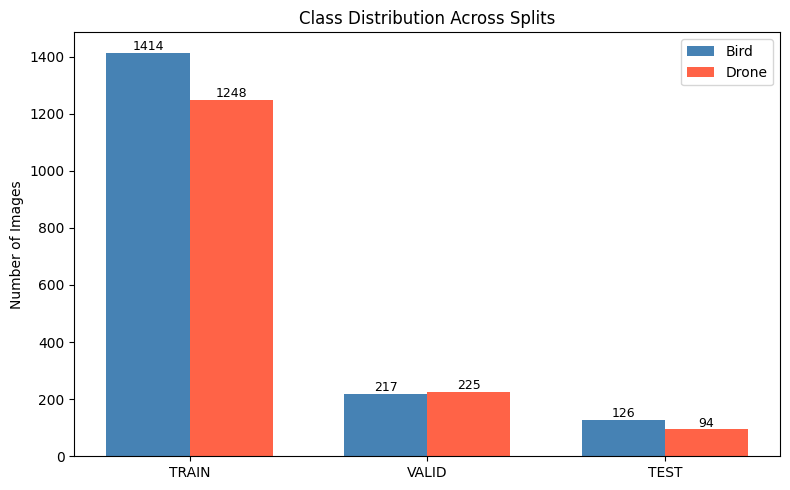

In [10]:
#Check Class Imbalance
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

splits = ['TRAIN', 'VALID', 'TEST']
paths = [TRAIN_DIR, VALID_DIR, TEST_DIR]
classes = ['bird', 'drone']

bird_counts = []
drone_counts = []

for path in paths:
    bird_counts.append(len(os.listdir(os.path.join(path, 'bird'))))
    drone_counts.append(len(os.listdir(os.path.join(path, 'drone'))))

x = np.arange(len(splits))
width = 0.35

fig, ax = plt.subplots(figsize=(8,5))
bars1 = ax.bar(x - width/2, bird_counts,  width, label='Bird',  color='steelblue')
bars2 = ax.bar(x + width/2, drone_counts, width, label='Drone', color='tomato')

ax.set_title('Class Distribution Across Splits')
ax.set_xticks(x)
ax.set_xticklabels(splits)
ax.set_ylabel('Number of Images')
ax.legend()

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 10,
            str(int(bar.get_height())),
            ha='center', fontsize=9)

plt.tight_layout()
plt.show()



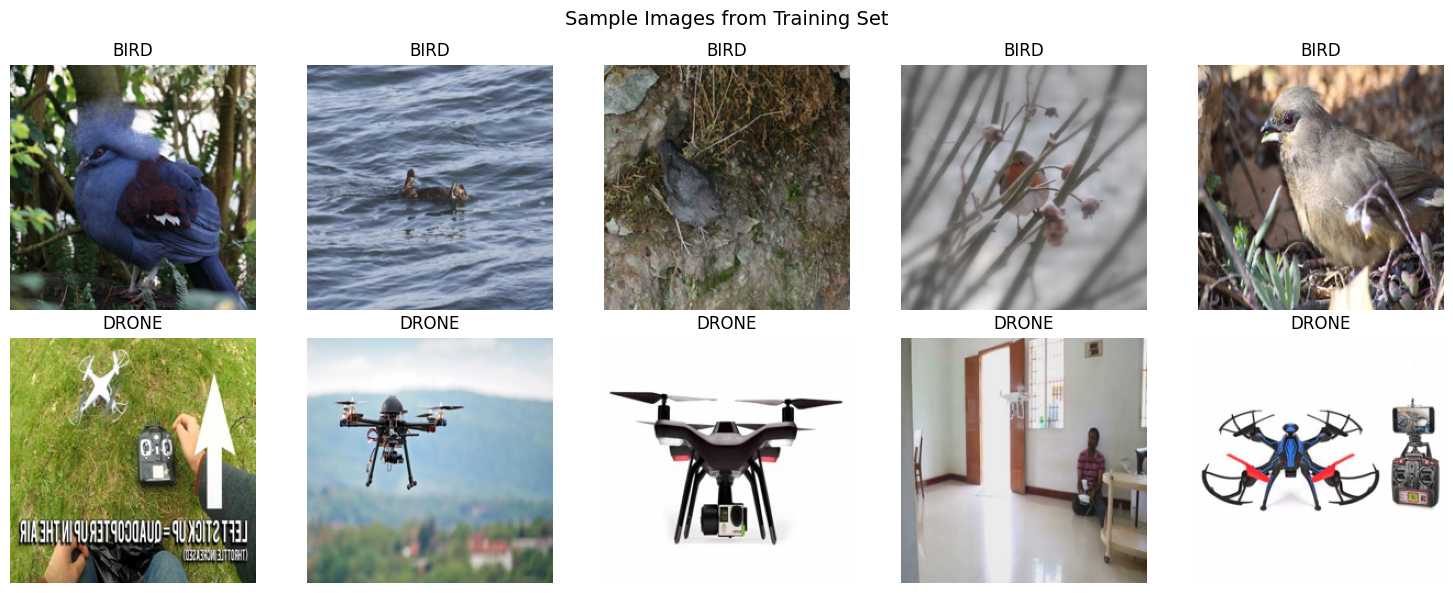

In [11]:
#vizualizing the samples image

from PIL import Image
import random

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Sample Images from Training Set', fontsize=14)

for idx, cls in enumerate(['bird', 'drone']):
    cls_path = os.path.join(TRAIN_DIR, cls)
    images = random.sample(os.listdir(cls_path), 5)
    for j, img_name in enumerate(images):
        img = Image.open(os.path.join(cls_path, img_name)).resize((224, 224))
        axes[idx][j].imshow(img)
        axes[idx][j].set_title(cls.upper())
        axes[idx][j].axis('off')

plt.tight_layout()
plt.show()

In [13]:
print(" Checking sample image sizes...\n")

for cls in ['bird', 'drone']:
    cls_path = os.path.join(TRAIN_DIR, cls)
    sample_images = random.sample(os.listdir(cls_path), 5)
    print(f"Class: {cls.upper()}")
    for img_name in sample_images:
        img = Image.open(os.path.join(cls_path, img_name))
        print(f"   {img_name} → Size: {img.size}, Mode: {img.mode}")
    print()

 Checking sample image sizes...

Class: BIRD
   0eb65a496e0f63b0_jpg.rf.99e873f3d0f04a121958ad96dba077df.jpg → Size: (416, 416), Mode: RGB
   0e756d31a261de5c_jpg.rf.8840aab13e8f2e5232456abe9717fefd.jpg → Size: (416, 416), Mode: RGB
   1729e371b5302426_jpg.rf.77b9371905d42b66fe78fbe85592534e.jpg → Size: (416, 416), Mode: RGB
   006579a947e00ec4_jpg.rf.a5fad7e2a8a2fb6e81b32b87f73eebe3.jpg → Size: (416, 416), Mode: RGB
   150a4c98f516934a_jpg.rf.49ed10205b2167978c706b234e660b60.jpg → Size: (416, 416), Mode: RGB

Class: DRONE
   pic_1146_jpg.rf.27a20680237f14a2a2ee9b2f9fda4298.jpg → Size: (416, 416), Mode: RGB
   foto05105_png.rf.ec6d94d83312d4607883ec10f6f50bfe.jpg → Size: (416, 416), Mode: RGB
   pic_701_jpg.rf.ccb8e3100c911bb912617797857c7188.jpg → Size: (416, 416), Mode: RGB
   pic_823_jpg.rf.d08626d7428b0240bcee825d81effda3.jpg → Size: (416, 416), Mode: RGB
   pic_455_jpg.rf.51223ad061ee830523f319cb665d50ba.jpg → Size: (416, 416), Mode: RGB



In [14]:
total_train = len(os.listdir(os.path.join(TRAIN_DIR, 'bird'))) + \
              len(os.listdir(os.path.join(TRAIN_DIR, 'drone')))

total_valid = len(os.listdir(os.path.join(VALID_DIR, 'bird'))) + \
              len(os.listdir(os.path.join(VALID_DIR, 'drone')))

total_test  = len(os.listdir(os.path.join(TEST_DIR, 'bird'))) + \
              len(os.listdir(os.path.join(TEST_DIR, 'drone')))

print("=" * 35)
print("📊 DATASET SUMMARY")
print("=" * 35)
print(f"Total Train Images : {total_train}")
print(f"Total Valid Images : {total_valid}")
print(f"Total Test  Images : {total_test}")
print(f"Total Images       : {total_train + total_valid + total_test}")
print(f"Classes            : Bird, Drone")
print("=" * 35)

📊 DATASET SUMMARY
Total Train Images : 2662
Total Valid Images : 442
Total Test  Images : 220
Total Images       : 3324
Classes            : Bird, Drone


 Data Preprocessing & Augmentation

In [15]:
from google.colab import drive
drive.mount('/content/drive')

import os

base = '/content/drive/MyDrive/Aerial Object Classification & Detection'

TRAIN_DIR = os.path.join(base, 'train-20260409T091319Z-3-001/train/')
VALID_DIR = os.path.join(base, 'valid-20260409T091319Z-3-001/valid/')
TEST_DIR  = os.path.join(base, 'test-20260409T091319Z-3-001/test/')

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [17]:
#Create Data Generators

# Training - with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True,
    vertical_flip=False,
    zoom_range=0.2,
    brightness_range=[0.8, 1.2],
    shear_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1)

# Validation & Test - only normalization
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Train generator
train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True)

# Validation generator
val_gen = val_test_datagen.flow_from_directory(
    VALID_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False)

# Test generator
test_gen = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False)
print(f"Class Indices: {train_gen.class_indices}")

Found 2662 images belonging to 2 classes.
Found 442 images belonging to 2 classes.
Found 220 images belonging to 2 classes.
Class Indices: {'bird': 0, 'drone': 1}


In [19]:
images, labels = next(train_gen)

print("=" * 35)
print(" BATCH INFO")
print("=" * 35)
print(f"Image Batch Shape : {images.shape}")
print(f"Label Batch Shape : {labels.shape}")
print(f"Pixel Value Range : {images.min():.2f} → {images.max():.2f}")
print(f"Sample Labels     : {labels[:5]}")
print(f"  (0=bird, 1=drone)" if train_gen.class_indices['bird']==0 else "  (0=drone, 1=bird)")
print("=" * 35)

 BATCH INFO
Image Batch Shape : (32, 224, 224, 3)
Label Batch Shape : (32,)
Pixel Value Range : 0.00 → 1.00
Sample Labels     : [1. 0. 1. 1. 0.]
  (0=bird, 1=drone)


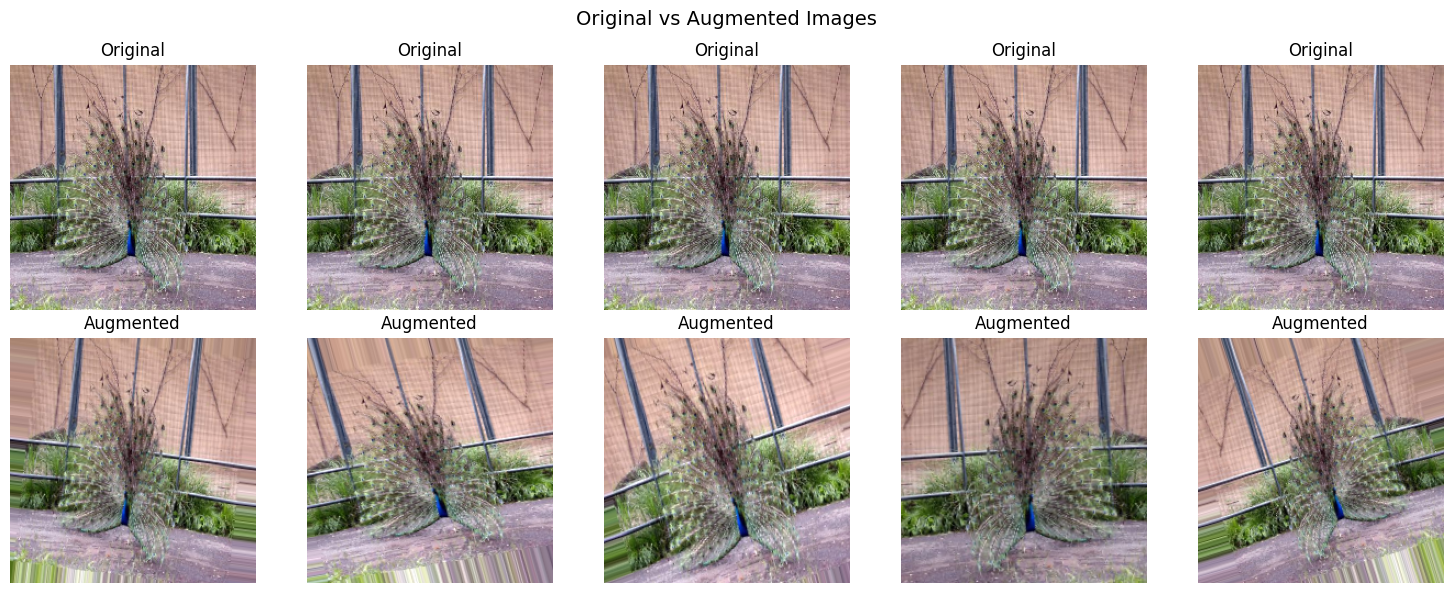

In [20]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Pick one sample image
sample_img_path = os.path.join(TRAIN_DIR, 'bird')
sample_img_name = os.listdir(sample_img_path)[0]
sample_img_full = os.path.join(sample_img_path, sample_img_name)

# Load image
img = load_img(sample_img_full, target_size=IMG_SIZE)
img_array = img_to_array(img)
img_array = img_array.reshape((1,) + img_array.shape)

# Augmentation generator
aug_gen = ImageDataGenerator(
    rotation_range=20,
    horizontal_flip=True,
    zoom_range=0.2,
    brightness_range=[0.8, 1.2],
    shear_range=0.1)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Original vs Augmented Images', fontsize=14)

# Original
for i in range(5):
    axes[0][i].imshow(img)
    axes[0][i].set_title('Original')
    axes[0][i].axis('off')

# Augmented
aug_iter = aug_gen.flow(img_array, batch_size=1)
for i in range(5):
    aug_img = next(aug_iter)[0].astype('uint8')
    axes[1][i].imshow(aug_img)
    axes[1][i].set_title('Augmented')
    axes[1][i].axis('off')

plt.tight_layout()
plt.show()

In [22]:
print(f"Image Size     : {IMG_SIZE}")
print(f"Batch Size     : {BATCH_SIZE}")
print(f"Train Batches  : {len(train_gen)}")
print(f"Valid Batches  : {len(val_gen)}")
print(f"Test Batches   : {len(test_gen)}")
print(f"Class Indices  : {train_gen.class_indices}")
print(f"Train Samples  : {train_gen.samples}")
print(f"Valid Samples  : {val_gen.samples}")
print(f"Test Samples   : {test_gen.samples}")
print("Preprocessing Complete")

Image Size     : (224, 224)
Batch Size     : 32
Train Batches  : 84
Valid Batches  : 14
Test Batches   : 7
Class Indices  : {'bird': 0, 'drone': 1}
Train Samples  : 2662
Valid Samples  : 442
Test Samples   : 220
Preprocessing Complete
